# Artificial Non-Streaming Demo

This notebook mirrors the lean ZINC non-streaming demo, but uses an artificial NetworkX dataset generated in memory.

- source: cycle -> connector path -> star-ray graphs
- sample count: `DATASET_SIZE`
- fit mode: materialize generated graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import random
import sys
from pathlib import Path

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.synthetic import generate_artificial_dataset


PyTorch version: 2.12.0+cpu
CUDA available: False


In [2]:
RANDOM_SEED = 7
DATASET_SIZE = 5000
CYCLE_LENGTH = 6
PATH_LENGTH = 4
NUM_RAYS = 0
RAY_LENGTH = 0
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True
FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
EMBEDDING_DIM = 64
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

ARTIFICIAL_NODE_LABEL_COLORS = {
    0: '#fee2e2',
    1: '#fca5a5',
    2: '#dc2626',
    3: '#dbeafe',
    4: '#93c5fd',
    5: '#2563eb',
    6: '#dcfce7',
    7: '#86efac',
    8: '#16a34a',
}


Saved artificial dataset config: artificial_dataset_config_20260526_175926_144020.yaml
Loaded 5000 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 10/10/10
Edge count min/median/max = 10/10/10
Metadata: {'cycle_length': 6, 'path_length': 4, 'num_rays': 0, 'ray_length': 0, 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}


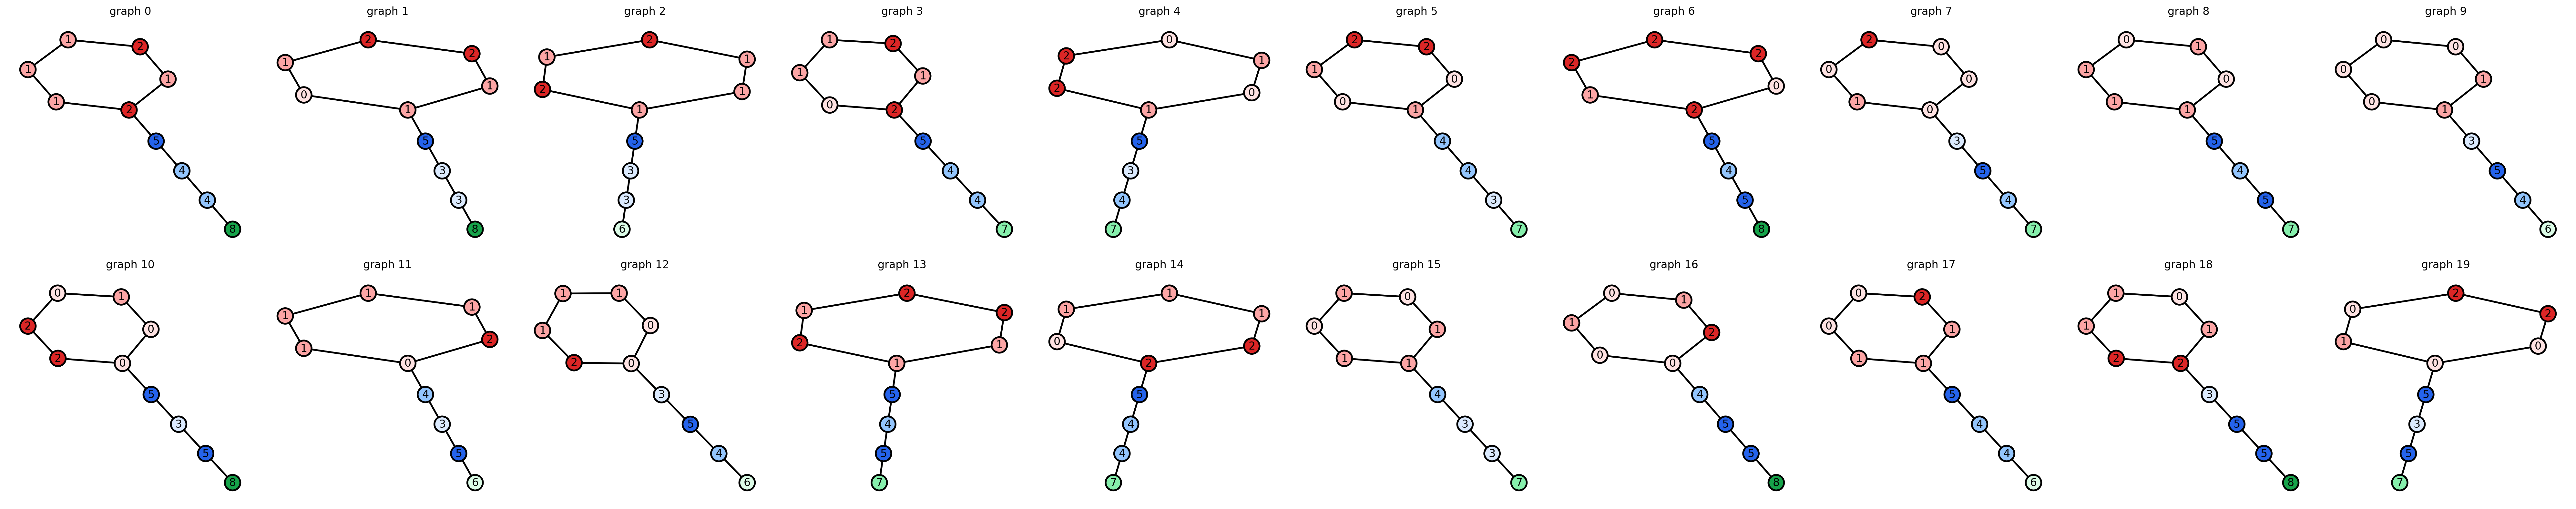

Configured graph generator model_name=artificial-cycle-path-star-n5000-c6-p4-r0x0-d64-b128-e350 model_dir=/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators


In [3]:
graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    cycle_length=CYCLE_LENGTH,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

plot_networkx_graphs(
    graphs[:20],
    n_cols=10,
    titles=[f'graph {idx}' for idx in range(20)],
    node_label_colors=ARTIFICIAL_NODE_LABEL_COLORS,
)

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.9,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=2,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_networkx_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
        node_label_colors=ARTIFICIAL_NODE_LABEL_COLORS,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs


In [ ]:
%%time
graph_generator.fit(
    graphs,
    sample_training_progress=True,
    sample_training_progress_n_samples=3,
    sample_training_progress_every_n_epochs=1,
)
print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Fit target model_name=artificial-cycle-path-star-n5000-c6-p4-r0x0-d64-b128-e350 model_dir=/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators
Fitting model on 5000 graphs


Fitting feasibility estimator on 5000 graphs
Finished fitting feasibility estimator in 0m 28.8s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 2 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=learned, enabled, horizon=2. Use horizon-2 locality as auxiliary regularization.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 300000 pairs (50.00%) from 600000 total pairs (pos=200000, neg=400000, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=100000, neg=200000, positive_ratio=0.333.
adj_mtx_to_targets[aux_locality, horizon=2]: sampling 435000 pairs (50.00%) from 870000 total pairs (pos=420000, neg=450000, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_m

/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


epoch 1: finished validation in 3.33s
epoch 1: starting validation


In [ ]:
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = f'{MODEL_NAME}.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


In [ ]:
raw_samples = graph_generator.sample(
    n_samples=7,
    apply_feasibility_filtering=False,
)
plot_networkx_graphs(
    raw_samples,
    n_cols=7,
    titles=[f'raw {idx}' for idx in range(len(raw_samples))],
    node_label_colors=ARTIFICIAL_NODE_LABEL_COLORS,
)


In [ ]:
if graph_generator.feasibility_estimator is None:
    print('Feasibility estimator is unavailable in this environment; skipping filtered sampling.')
else:
    filtered_samples = graph_generator.sample(
        n_samples=7,
        apply_feasibility_filtering=True,
    )
    plot_networkx_graphs(
        filtered_samples,
        n_cols=7,
        titles=[f'filtered {idx}' for idx in range(len(filtered_samples))],
        node_label_colors=ARTIFICIAL_NODE_LABEL_COLORS,
    )
